In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm, expm_multiply, spsolve, norm
from scipy.optimize import curve_fit

from schrodingerization_utils import *

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, operators
from qiskit import transpile
from qiskit_aer import AerSimulator
from ionq_circuit_utils import save_as_native_circuit, get_circuit_from_qiskit, get_native_circuit, get_native_gate_counts, \
    get_ionq_job_json, send_job, cancel_job, get_ionq_single_job_result

import hashlib
import json

from simuq import QSystem
from simuq import Qubit
from simuq.ionq import IonQProvider, IonQAPICircuit

from os.path import join

from dotenv import load_dotenv
load_dotenv()

from ionq_circuit_utils import *
import sys
sys.path.append(join(".", ".."))
from utils import *

In [3]:
DATA_DIR = join("..", "experiment_data")
TASK_DIR = "schrodingerization"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
else:
    device = "simulator"
print("Device:", device)

../experiment_data/schrodingerization
Device: simulator


# Schrodingerization for non-Hermitian spin systems

We want to simulate
$$
    u'(t) = A u(t)\\
    u(0) = u_0,
$$
where 
$$
    A=-i\left(J\sum_{j=1}^{n_x-1} Z_j Z_{j+1} + h\sum_{j=1}^{n_x} X_j \right) + \gamma\sum_{j=1}^{n_x} (Z_j - I)
$$

So, $A=H_1 + iH_2$ where
\begin{align}
    H_1 &= \gamma \sum_{j=1}^{n_x} (Z_j - I),\\
    H_2 &=-\left(J\sum_{j=1}^{n_x-1} Z_j Z_{j+1} + h\sum_{j=1}^{n_x} X_j \right).
\end{align}

In [4]:
def simuq_laplace_dist_qft(n_x, n_p, R):
    N_p = 2 ** n_p
    h = (2 * R) / (N_p - 1)
    
    state_prep_circ = IonQAPICircuit(n_x + n_p)
    for i in range(n_p-1):
        theta = 2 * np.arccos(1 / np.sqrt(1 + np.exp(-2 * (2 ** i) * h)))
        state_prep_circ.ry(int(i), theta)
    # Make symmetric
    state_prep_circ.hadamard(int(n_p - 1))
    for i in range(n_p-1):
        state_prep_circ.cnot(int(n_p - 1), int(i))
    state_prep_circ.rx(int(n_p - 1), np.pi)

    return state_prep_circ

def simuq_qft(n_x, n_p, approx_degree=0):
    qft_circ = IonQAPICircuit(n_x + n_p)
    for i in np.arange(n_p)[::-1]:
        # myqft.ry(-np.pi/4, n_p - 1 - i)
        # myqft.rz(np.pi, n_p - 1 - i)
        qft_circ.hadamard(int(i))
        for j in range(i):
            if j < n_p - 1 - approx_degree:
                theta = np.pi / (2 ** (j + 1))
                # Controlled phase gate
                qft_circ.rz(int(i), theta / 2)
                qft_circ.rz(int(i - 1 - j), theta / 2)
                qft_circ.rzz(int(i), int(i - 1 - j), -theta / 2)
    for i in range(n_p // 2):
        qft_circ.rxx(i, n_p - 1 - i, np.pi / 2)
        qft_circ.ryy(i, n_p - 1 - i, np.pi / 2)
        qft_circ.rzz(i, n_p - 1 - i, np.pi / 2)
    return qft_circ

def simuq_iqft(n_x, n_p, approx_degree=0):
    qft_circ = IonQAPICircuit(n_x + n_p)

    for i in range(n_p // 2):
        qft_circ.rxx(int(i), int(n_p - 1 - i), np.pi / 2)
        qft_circ.ryy(int(i), int(n_p - 1 - i), np.pi / 2)
        qft_circ.rzz(int(i), int(n_p - 1 - i), np.pi / 2)

    for i in np.arange(n_p):
        for j in range(i):
            if j < n_p - 1 - approx_degree:
                theta = -np.pi / (2 ** (j + 1))
                # Controlled phase gate
                qft_circ.rz(int(i), theta / 2)
                qft_circ.rz(int(i - 1 - j), theta / 2)
                qft_circ.rzz(int(i), int(i - 1 - j), -theta / 2)
        
        qft_circ.hadamard(i)
    return qft_circ

In [5]:
def simuq_schrodingerization(n_x, n_p, R, t, J, h, gamma):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(n_x + n_p)]
    H_1 = 0
    H_2 = 0
    # TFIM part
    for j in range(n_x):
        H_2 -= h * q[n_p+j].X
    for j in range(n_x-1):
        H_2 -= J * q[n_p+j].Z * q[n_p+j+1].Z
    # Longitudinal field
    for j in range(n_x):
        H_1 -= gamma * (q[n_p+j].I - q[n_p+j].Z)

    H_d = q[0].I
    H_d -= (2 ** (n_p - 1)) * q[n_p-1].Z
    for i in range(n_p-1):
        H_d += (2 ** i) * q[i].Z
    
    H_d *= (-1/2)
    H_F = (np.pi / R) * H_d
    H = H_1 * H_F - H_2
    qs.add_evolution(H, t)
    return qs

def run_schrodingerization_simuq(experiment_info, device, save_dir, 
             job_ids_filename, noisy_simulator=False):
    
    np.random.seed(0)
    
    t_vals = np.linspace(0, experiment_info["T"], experiment_info["N_t"])

    job_ids = []
    for i, t in enumerate(t_vals):

        print(f"Running t = {t:0.2f}")
            
        provider = IonQProvider(api_key=IONQ_API_KEY)

        '''State preparation and QFT'''
        state_prep_iqft_circ = simuq_laplace_dist_qft(experiment_info["n_x"], experiment_info["n_p"], experiment_info["R"]).add(simuq_iqft(experiment_info["n_x"], experiment_info["n_p"]))

        schrodingerization_qs = simuq_schrodingerization(experiment_info["n_x"], experiment_info["n_p"], experiment_info["R"], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
        assert schrodingerization_qs.num_sites == len(state_prep_iqft_circ._accum_phases)
        
        qft_circ = simuq_qft(experiment_info["n_x"], experiment_info["n_p"])

        provider.compile(schrodingerization_qs, trotter_mode=2, trotter_num=experiment_info["r"], state_prep=state_prep_iqft_circ.copy(), meas_prep=qft_circ.copy(), tol=0.1)
        # provider.compile(schrodingerization_qs, trotter_mode=2, trotter_num=experiment_info["r"], tol=0.1)
        # print(provider.prog)
        # Wait before sending the job
        if device == "simulator":
            provider.run(experiment_info["num_shots"], on_simulator=True, with_noise=noisy_simulator, verbose=-1)
        else:
            print("Running on real machine")
            provider.run(experiment_info["num_shots"], on_simulator=False, verbose=-1)
        # Get the job id
        job_id = provider.task['id']
        print("Job id:", job_id)
        job_ids.append(job_id)

    # Save the job ids
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()
    print()
    print("Finished.")

Experiment parameters

In [6]:
'''Modifiable parameters'''
n_p = 5                        # Number of qubits for p
n_x = 3                         # Number of qubits for x
R = 8                           # Right boundary endpoint
T = 2                          # Evolution time
N_t = 16                        # Number of time points
r = 4                           # Number of Trotter steps
J = 1
h = 1
gamma = 0.05  
num_shots = 5000                # Number of shots
trotter_method = "second_order"
qft_approx_degree = 0

N_p = 2 ** n_p
h_p = (2 * R) / (N_p - 1)
p = np.linspace(-R, R, N_p)
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
t_vals = np.linspace(0, T, N_t)

H_1 = - gamma * sum_delta_n(n_x, delta=2 * np.ones(n_x))
H_2 = - (h * sum_x(n_x) + J * sum_J_zz(n_x, diags([np.ones(n_x-1)], [1]).toarray()))

A = H_1 + 1j * H_2

print("H1:", H_1.toarray())
print("H2:", H_2.toarray())
print(f"Norm of H1: {np.linalg.norm(H_1.toarray(), ord=2):0.3f}")
print(f"Norm of H2: {np.linalg.norm(H_2.toarray(), ord=2):0.3f}")

N_p: 32
Total number of qubits: 8
H1: [[ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.1  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.1  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.2  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.1  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.2  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.2  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.3]]
H2: [[-2. -1. -1.  0. -1.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.]
 [-1.  0.  2. -1.  0.  0. -1.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0. -1.  0.  0. -1.  2.  0. -1.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.]
 [ 0.  0.  0. -1.  0. -1. -1. -2.]]
Norm of H1: 0.300
Norm of H2: 3.494


In [7]:
experiment_info = {
    "n_p": n_p,
    "n_x": n_x,
    "R": R,
    "T": T,
    "N_t": N_t,
    "r": r,
    "h": h,
    "J": J,
    "gamma": gamma,
    "num_shots": num_shots,
    "trotter_method": trotter_method,
    "qft_approx_degree": qft_approx_degree
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

if device == "simulator":
    job_ids_filename = 'job_ids_sim.json'
else:
    job_ids_filename = 'job_ids_qpu.json'

Save dir: ../experiment_data/schrodingerization/863a7fac7e74198a85f2db4b0f47fcbd


Ground truth

In [8]:
hamming_weight_operator = np.zeros(2 ** n_x)
for i in range(2 ** n_x):
    hamming_weight_operator[i] = i.bit_count()

In [9]:
psi_0 = np.zeros(2 ** n_x)
psi_0[0] = 1
# psi_0 = np.ones(2 ** n)
# psi_0 /= np.linalg.norm(psi_0)
psi = expm_multiply(A, psi_0, start=0, stop=T, num=N_t)

obs_gt = np.zeros(N_t)
for i in range(N_t):
    obs_gt[i] = np.real(np.conj(psi[i]) @ (hamming_weight_operator * psi[i]))

In [10]:
u_recover_ft = schrodingerization_ft(A, psi_0, N_p, R, T, N_t, 0, r)
# u_recover_ft_trot = schrodingerization_ft_trot(A, psi_0, N_p, R, T, N_t, 0, r)


obs_schrodingerization_ft = np.zeros(N_t)
for i in range(N_t):
    obs_schrodingerization_ft[i] = np.real(np.conj(u_recover_ft[i]) @ (hamming_weight_operator * u_recover_ft[i]))

(256, 256)


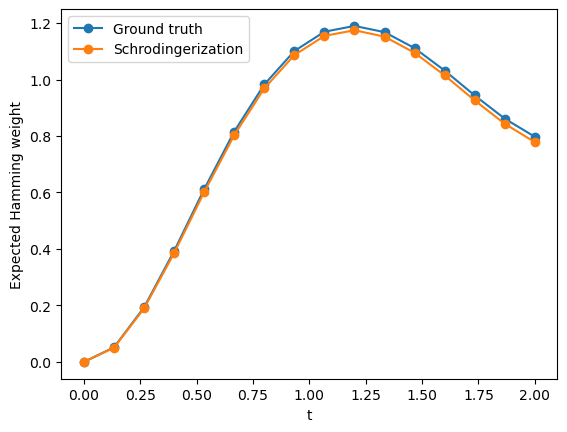

In [11]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, obs_schrodingerization_ft, '-o', label="Schrodingerization")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend()
plt.show()

In [13]:
def run_schrodingerization(experiment_info, device, save_dir, job_ids_filename, noisy_simulator=False):
    print("Running Schrodingerization")

    H_1 = - experiment_info["gamma"] * sum_delta_n(experiment_info["n_x"], delta=2 * np.ones(experiment_info["n_x"]))
    H_2 = - (experiment_info["h"] * sum_x(experiment_info["n_x"]) + experiment_info["J"] * sum_J_zz(experiment_info["n_x"], diags([np.ones(experiment_info["n_x"]-1)], [1]).toarray()))
    # A = H_1 + 1j * H_2

    t_vals = np.linspace(0, experiment_info["T"], experiment_info["N_t"])
    job_ids = []
    for i, t in enumerate(t_vals):
        print(f"Running t = {t:0.2f}")

        # Get the circuit and transpile it, removing SWAP gates
        circuit = get_full_circuit(experiment_info["n_x"], 
                                   experiment_info["n_p"], 
                                   t, 
                                   H_1, 
                                   H_2, 
                                   experiment_info["r"], 
                                   experiment_info["R"],
                                   trotter_method=experiment_info["trotter_method"], 
                                   qft_approx_degree=experiment_info["qft_approx_degree"])

        compiled_circuit, current_permutation = process_swaps(transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2))
        assert current_permutation == list(range(experiment_info["n_x"]+experiment_info["n_p"]))

        # Check that SWAP gates do not affect the result when transpiled
        # U1 = Operator(circuit).to_matrix()
        # U2 = Operator(compiled_circuit).to_matrix()
        # assert 1 - np.abs(np.trace(U1 @ np.conj(U2.T))) / 2 ** (experiment_info["n_x"]+experiment_info["n_p"]) < 1e-6, "Check compiled circuit matches the original circuit!"

        instructions = get_circuit_from_qiskit(compiled_circuit)
        native_instructions, qubit_phase = get_native_circuit(experiment_info["n_x"]+experiment_info["n_p"], instructions)
        single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
        print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")
        
        # Create the job json and save it
        job = get_ionq_job_json("schrodingerization", experiment_info["n_x"]+experiment_info["n_p"], experiment_info["num_shots"], device, instructions, noisy_simulator=noisy_simulator)
        
        print(f"Saving in {save_dir}")
        with open(join(save_dir, f"job_{i}.json"), "w") as f:
            json.dump(job, f, default=int)

        # Send the job and get the job id
        job_id = send_job(job)
        print("Job id:", job_id)
        job_ids.append(job_id)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()


# Run on IonQ simulator or real machine

In [255]:
# Real machine
# run_schrodingerization(experiment_info, "qpu.aria-1", SAVE_DIR, "job_ids_qpu.json")

In [235]:
device = "qpu.aria-1"
job_ids_filename = "job_ids_qpu_simuq.json"
run_schrodingerization_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, noisy_simulator=False)

Running t = 0.00
Running on real machine
Job id: 5162c87c-1057-4eb1-90b4-1dcab80abcb9
Running t = 0.13
Running on real machine
Job id: f4407d61-b0d0-4db9-9b10-231dff0508b1
Running t = 0.27
Running on real machine
Job id: aa83c5a2-a2dd-42e1-aa21-f1c673f1776d
Running t = 0.40
Running on real machine
Job id: 6eb91d5e-44d1-4a6f-a2d8-92a9dca38271
Running t = 0.53
Running on real machine
Job id: ffd6a6b5-d50e-4ff7-81a1-6e2a9b9f453c
Running t = 0.67
Running on real machine
Job id: 8304b35e-218f-4191-b355-259359caacbd
Running t = 0.80
Running on real machine
Job id: 8e631469-8ecf-4915-923b-7cc1234ad855
Running t = 0.93
Running on real machine
Job id: 499d0723-2123-4e79-99bb-fe9c59e7b38a
Running t = 1.07
Running on real machine
Job id: 68e8338b-94ae-49b4-8179-02eb69b5d49f
Running t = 1.20
Running on real machine
Job id: ff43b4c5-a4a5-492b-a907-b1346677761e
Running t = 1.33
Running on real machine
Job id: 957c1e0e-847f-49a9-a00a-46da000e8225
Running t = 1.47
Running on real machine
Job id: 8dbed

In [107]:
device = "simulator"
job_ids_filename = "job_ids_noisy_sim_simuq.json"
run_schrodingerization_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, noisy_simulator=True)

Running t = 0.00
Job id: 4143b392-5e7d-4486-a053-183f44bb6a20
Running t = 0.13
Job id: b9819394-2770-4057-9cdb-4ed9726207fe
Running t = 0.27
Job id: 0a62aad1-15b3-4780-a2dc-aa129d9298c0
Running t = 0.40
Job id: 526e900f-fb66-4fec-8d39-6a838928dc59
Running t = 0.53
Job id: 954c3060-bbef-4f04-98df-9c62efff3954
Running t = 0.67
Job id: 37afb4ba-c981-480f-88b1-72e52cb142e2
Running t = 0.80
Job id: f7038901-b915-4835-a5e7-e52a586d5c01
Running t = 0.93
Job id: e726c732-4f62-41c2-ad74-b09a28023630
Running t = 1.07
Job id: 3212b723-8ee5-4628-974c-8d801e55de58
Running t = 1.20
Job id: ffd4495a-6acc-4fad-a28a-af98f4704fd6
Running t = 1.33
Job id: 0b906b6b-1075-4faa-833d-35ffa4d03a5d
Running t = 1.47
Job id: 34750138-5795-4594-95d7-072f23b4fe9e
Running t = 1.60
Job id: b5cb395a-397c-4470-a96d-b1d6db225510
Running t = 1.73
Job id: 9f06b086-f760-489c-960a-9dc0a355b7c5
Running t = 1.87
Job id: 1640f988-cadd-4c26-9bd5-7f2d27fcf144
Running t = 2.00
Job id: d0d31a15-16c7-46f5-be98-f0f4299a288d

Finishe

In [237]:
device = "simulator"
job_ids_filename = "job_ids_sim_simuq.json"
run_schrodingerization_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, noisy_simulator=False)

Running t = 0.00
Job id: 02931a2e-828c-4ae3-b2e0-346bb706b70c
Running t = 0.13


Job id: 8adfa684-4e25-4482-af2f-4156b89fcccc
Running t = 0.27
Job id: e849a786-0d1c-4f96-a2a3-bdc621d35ed7
Running t = 0.40
Job id: 68063271-1530-4bf7-8f8a-dde58cb2045d
Running t = 0.53
Job id: e7881b1a-66d4-4e77-95e5-c727a3cbdb70
Running t = 0.67
Job id: f9259fa1-0d79-4dc7-8e77-2debff3a7aba
Running t = 0.80
Job id: 662a2ca3-2fe2-4dc3-acc7-f5248d336d10
Running t = 0.93
Job id: a59f1982-e0a0-4fec-9999-1367dca115f1
Running t = 1.07
Job id: f4871411-144a-4576-9670-9880979072ad
Running t = 1.20
Job id: f3a73ef0-5ba4-4d6d-b6dc-55300b332039
Running t = 1.33
Job id: 48f96c02-a3f5-4d96-8871-439827032c82
Running t = 1.47
Job id: 33bd01b3-0459-4264-afdc-8ad38c1c82b8
Running t = 1.60
Job id: 4455f085-8a4a-4e9c-8186-faf79665e287
Running t = 1.73
Job id: e3fa1475-00ce-4264-a474-18f55574755f
Running t = 1.87
Job id: 18110888-463c-46c9-b77b-393832ef33e3
Running t = 2.00
Job id: 1d0446db-13e3-419d-9538-aa14fc6d4df9

Finished.


# Post processing

In [14]:
def post_processing(experiment_info, job_ids_filename, save_dir, use_correction=False):
    dimension = 2 ** experiment_info["n_x"]
    N_p = 2 ** experiment_info["n_p"]
    h = (2 * experiment_info["R"]) / (N_p - 1)

    # Get the job ids
    with open(join(save_dir, job_ids_filename), "r") as f:
        job_ids = json.load(f)
        f.close()

    obs_schrodingerization = np.zeros((experiment_info["N_t"]))
    std_error = np.zeros((experiment_info["N_t"]))
    # normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * experiment_info["R"])) / h_p)
    # normalization_factor_state_prep = np.linalg.norm(np.exp(-np.abs(p)))
    # Get the job results
    for i, job_id in enumerate(job_ids):
        
        results = get_ionq_single_job_result(job_id)

        freq = np.zeros(2 ** (experiment_info["n_p"] + experiment_info["n_x"]))
        for j in range(2 ** (experiment_info["n_p"] + experiment_info["n_x"])):
            if str(j) in results.keys():
                freq[j] = results[str(j)]
        freq_reshaped = np.reshape(freq, newshape=(dimension, N_p))
        # a = np.sum(p * np.sum(freq_reshaped, axis=0))

        if use_correction:
            a = p[np.argmax(np.sum(freq_reshaped, axis=0))]
            # print(f"a={a}")
            a = max(a, 0)
        else:
            a = 0


        laplace_dist = np.exp(-np.abs(p-a))
        laplace_dist /= np.linalg.norm(laplace_dist)
        # laplace_dist *= np.sqrt(np.max(np.sum(freq_reshaped, axis=0)))
        # plt.plot(p, np.abs(laplace_dist) ** 2, label="Laplace dist squared", color="blue", alpha=0.5)
        # plt.plot(p, np.sum(freq_reshaped, axis=0), label="Simulated probability", color="red", alpha=0.5)
        # plt.legend()
        # plt.show()

        # lambda_min = -norm(b)/2
        # a = -lambda_min * t
        assert 0 <= a < R, "a is not within [0,R], increase R"
        a_idx = N_p // 2 + int(a / h)
        # for j in range(dimension):
        #     plt.plot(p, np.sqrt(freq_reshaped[j,:]), label=f"x_{j}")
        # plt.title(f"Uncorrected distribution t={t_vals[i]:0.2f}")
        # plt.xlabel("p")
        # plt.ylabel("Frequency")
        # plt.legend()
        # plt.show()

        obs_schrodingerization[i] = 2 * np.sum(np.sum(freq_reshaped[:,a_idx:], axis=1) * hamming_weight_operator)
        
        num_samples_valid = np.sum(np.sum(freq_reshaped[:,a_idx:], axis=1)) * experiment_info["num_shots"]
        print("Num samples p>=0:", np.round(num_samples_valid))
        std_error[i] = np.sqrt(np.sum(np.sum(freq_reshaped[:,a_idx:], axis=1) * (2 * hamming_weight_operator - obs_schrodingerization[i])**2) / (num_samples_valid - 1))
        

    return obs_schrodingerization, std_error

Get the results

In [15]:
# job_ids_filename = "job_ids_sim.json"
# obs_schrodingerization_sim = post_processing(experiment_info, job_ids_filename, SAVE_DIR, use_correction=False)

In [16]:
job_ids_filename = "job_ids_sim_simuq.json"
observable_sim_simuq, std_error_sim_simuq = post_processing(experiment_info, job_ids_filename, SAVE_DIR, use_correction=False)

Getting job: 2c4a01f8-9b49-4fe9-8f74-242a0474ce80
Job status: completed
Num samples p>=0: 2499.0
Getting job: 0d85f535-4d25-4b4f-8ece-bb9d1cc19544
Job status: completed
Num samples p>=0: 2494.0
Getting job: 38e69f83-e03e-4fb3-a744-13d4298309d0
Job status: completed
Num samples p>=0: 2490.0
Getting job: 47da5918-3b9b-49b6-b40a-2e038066fe0c
Job status: completed
Num samples p>=0: 2473.0
Getting job: bcd85ac1-95e5-4c7d-b1b3-8229ca468ab1
Job status: completed
Num samples p>=0: 2443.0
Getting job: 9b9f810d-ad06-49ad-bea0-95c1fc81bf62
Job status: completed
Num samples p>=0: 2403.0
Getting job: 4075d3ae-fe77-426e-942a-d8d5be6c9b64
Job status: completed
Num samples p>=0: 2349.0
Getting job: 31b51c8d-94a3-4af3-b880-257bb6161837
Job status: completed
Num samples p>=0: 2284.0
Getting job: 520b7728-c928-482f-83f5-ca4f467b4e01
Job status: completed
Num samples p>=0: 2214.0
Getting job: e1fea8c3-d9e0-4862-adf0-37eec4305827
Job status: completed
Num samples p>=0: 2139.0
Getting job: 9e139707-665b-483

In [26]:
job_ids_filename = "job_ids_noisy_sim_simuq.json"
observable_noisy_simuq, std_error_noisy_simuq = post_processing(experiment_info, job_ids_filename, SAVE_DIR, use_correction=False)

Getting job: 4143b392-5e7d-4486-a053-183f44bb6a20
Job status: completed
Num samples p>=0: 2519.0
Getting job: b9819394-2770-4057-9cdb-4ed9726207fe
Job status: completed
Num samples p>=0: 2461.0
Getting job: 0a62aad1-15b3-4780-a2dc-aa129d9298c0
Job status: completed
Num samples p>=0: 2497.0
Getting job: 526e900f-fb66-4fec-8d39-6a838928dc59
Job status: completed
Num samples p>=0: 2444.0
Getting job: 954c3060-bbef-4f04-98df-9c62efff3954
Job status: completed
Num samples p>=0: 2453.0
Getting job: 37afb4ba-c981-480f-88b1-72e52cb142e2
Job status: completed
Num samples p>=0: 2423.0
Getting job: f7038901-b915-4835-a5e7-e52a586d5c01
Job status: completed
Num samples p>=0: 2488.0
Getting job: e726c732-4f62-41c2-ad74-b09a28023630
Job status: completed
Num samples p>=0: 2429.0
Getting job: 3212b723-8ee5-4628-974c-8d801e55de58
Job status: completed
Num samples p>=0: 2381.0
Getting job: ffd4495a-6acc-4fad-a28a-af98f4704fd6
Job status: completed
Num samples p>=0: 2383.0
Getting job: 0b906b6b-1075-4fa

In [18]:
job_ids_filename = "job_ids_qpu_simuq.json"
observable_qpu_simuq, std_error_qpu_simuq = post_processing(experiment_info, job_ids_filename, SAVE_DIR, use_correction=False)

Getting job: 8f6fd6b2-72be-4064-93a8-a707af96a924
Job status: completed
Num samples p>=0: 2030.0
Getting job: 56aed4fb-e7a9-4753-bf3f-a2dfef94000e
Job status: completed
Num samples p>=0: 2268.0
Getting job: 4636d99b-3e15-4a38-97b6-aa4aeb696663
Job status: completed
Num samples p>=0: 2222.0
Getting job: 749e81d8-4f64-4dd9-b2c0-f6899051bac8
Job status: completed
Num samples p>=0: 2067.0
Getting job: 8565a979-c6b8-4a63-b182-6f3ce9346be5
Job status: completed
Num samples p>=0: 2135.0
Getting job: b24481d0-9f2c-4c2b-b28a-390922342f7a
Job status: completed
Num samples p>=0: 2089.0
Getting job: 4983e7a5-98ee-4188-9b6a-76d1093b8cef
Job status: completed
Num samples p>=0: 1960.0
Getting job: 64952c58-e043-4491-8838-233ca0a2f547
Job status: completed
Num samples p>=0: 2019.0
Getting job: 4d1ed7d4-6f20-454e-bc0e-15a41b7f3af6
Job status: completed
Num samples p>=0: 2012.0
Getting job: d336a6c1-0ae2-41a2-adc9-55cdc2a2c735
Job status: completed
Num samples p>=0: 2007.0
Getting job: 331e9550-7c62-4df

In [27]:
np.savez(join("..", "experiment_data", "schrodingerization_tfim_data.npz"), 
         t_vals=t_vals,
         obs_gt=obs_gt,
         observable_sim_simuq=observable_sim_simuq,
         std_error_sim_simuq=std_error_sim_simuq,
         observable_noisy_simuq=observable_noisy_simuq,
         std_error_noisy_simuq=std_error_noisy_simuq,
         observable_qpu_simuq=observable_qpu_simuq,
         std_error_qpu_simuq=std_error_qpu_simuq)

In [30]:
data = np.load(join("..", "experiment_data", "schrodingerization_tfim_data.npz"))
obs_sim_simuq = data["observable_sim_simuq"] 
std_error_sim_simuq = data["std_error_sim_simuq"]
observable_qpu_simuq = data["observable_qpu_simuq"]
std_error_qpu_simuq = data["std_error_qpu_simuq"]

# Plot the results

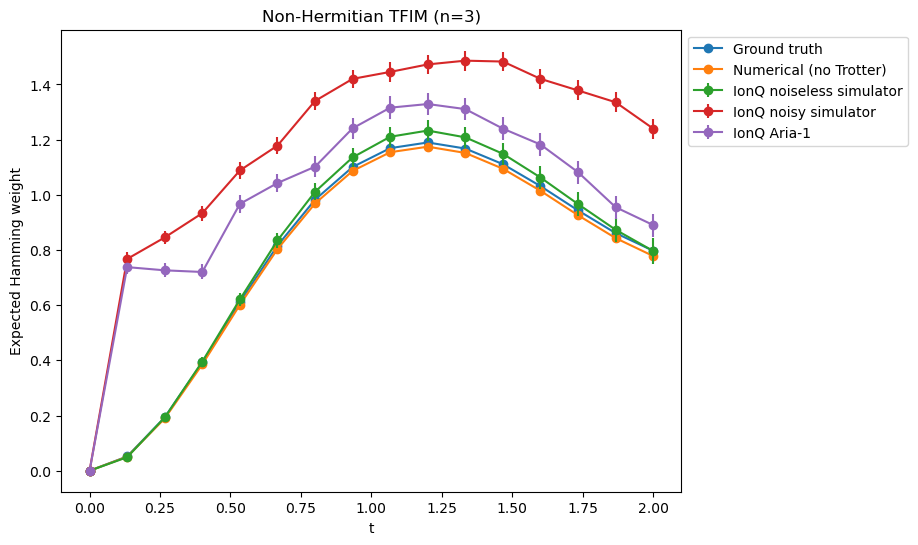

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, obs_schrodingerization_ft, '-o', label="Numerical (no Trotter)")
# plt.plot(t_vals, obs_schrodingerization_circ_sim, '-o', label=f"Circuit simulator ({num_shots} shots)")
# plt.plot(t_vals, obs_schrodingerization_circ, '-o', label="Circuit simulator (no sampling)")
plt.errorbar(t_vals, observable_sim_simuq, std_error_sim_simuq, fmt='-o', label=f'IonQ noiseless simulator')
plt.errorbar(t_vals, observable_noisy_simuq, std_error_noisy_simuq, fmt='-o', label=f'IonQ noisy simulator')
plt.errorbar(t_vals, observable_qpu_simuq, std_error_qpu_simuq, fmt='-o', label="IonQ Aria-1")

plt.title(f"Non-Hermitian TFIM (n={n_x})")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()